# nb11 — есть ли пары, которые всегда в минусе, и как отсеивать их заранее

Вопрос пользователя: «есть ли пары которые всегда сильно в минусе, и есть ли какие
то критерии по которым мы сможем в будущем отсеивать такие пары».

**Ловушка, которую надо обойти в первую очередь.** У нас 903 пары. Даже если все
они абсолютно одинаковы по своей природе, распределение их средних результатов
будет широким просто из-за конечного числа сделок, и «худшие» найдутся всегда.
Поэтому вопрос «есть ли плохие пары» сам по себе бессмысленный — на него ответ
всегда «да». Осмысленных вопросов три, и они идут строго по порядку:

1. **Больше ли разброс средних по парам, чем даёт чистый шум?** Если нет — никаких
   «плохих пар» не существует, есть только неудачные реализации. Меряется
   перестановочным тестом (перемешать сделки между парами, сохранив их число).
2. **Переносится ли «плохость» вперёд?** Ранжируем пары по одному периоду и
   смотрим результат следующего. Без этого фильтр по прошлому убытку — подгонка.
   Контроль надёжности: то же разбиение внутри одного периода (чётные/нечётные
   сделки) — если даже там связи нет, оценка по паре это шум.
3. **Есть ли НАБЛЮДАЕМЫЕ на момент входа признаки**, связанные с будущим убытком?
   Только такие годятся в фильтр. Признак «пара теряла в прошлом» — законный
   кандидат, но проверяется он так же, как остальные, out-of-time.

Материал — выжившая в nb10 конфигурация (формация 3 дня, ADF t<−3.8) плюс более
мягкая t<−3.4 для статистики по парам: там на пару приходится ~58 сделок вместо
~28, и оценка среднего по паре надёжнее.

Отдельно добавляю то, чего в наших PnL до сих пор **не было вообще: фандинг**.
Это реальный денежный поток, известный заранее, и он один из лучших кандидатов
в ex-ante фильтр — пара, где мы систематически платим за перенос, обязана быть
хуже.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from _engine import *
from dataclasses import replace
from itertools import combinations
from scipy import stats as sps
import time

MIN_DVOL_M = 5.0
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]
px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6
liq = sorted([s for s in px.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])
LP = np.log(px.loc[TRAIN[0]:TRAIN[1], liq]).iloc[:-1]
PAIRS = [((a, b) if daily_m[a] <= daily_m[b] else (b, a)) for a, b in combinations(liq, 2)]
bk = Book(LP, liq, PAIRS)
COST = ROUND_TRIP_BPS / 100
L = 3
R = refit(bk, bk.nbars(L), -3.4)
D = {}
for thr in [-3.4, -3.8]:
    D[thr] = sweep(bk, replace(R, thr=thr), "REFIT", cost_pct=COST)
    d = D[thr]
    print(f"L={L}д t<{thr}: {len(d)} сделок, {d.pair.nunique()} пар, "
          f"{len(d)/d.pair.nunique():.0f} сделок/пару, gross {d.gross.mean():+.4f}%")
MAIN = -3.4
FIT_END = pd.Timestamp("2025-01-01", tz="UTC")
print(f"\nразбиение: fit = до {FIT_END.date()}, test = после")
for thr, d in D.items():
    print(f"  t<{thr}: fit {(d.t_in < FIT_END).sum()} сделок, "
          f"test {(d.t_in >= FIT_END).sum()}")

L=3д t<-3.4: 52537 сделок, 903 пар, 58 сделок/пару, gross +0.0495%


L=3д t<-3.8: 25653 сделок, 903 пар, 28 сделок/пару, gross +0.0599%

разбиение: fit = до 2025-01-01, test = после
  t<-3.4: fit 34783 сделок, test 17754
  t<-3.8: fit 16982 сделок, test 8671


## 1. Разброс средних по парам — больше ли он, чем у шума?

Аналитически: если пары одинаковы, дисперсия их средних должна равняться
`E[σ²_внутри / n_i]` — целиком объясняться конечным числом сделок. Отношение
наблюдаемой дисперсии к этой ожидаемой и есть ответ. Рядом — перестановочный тест:
перемешиваем сделки между парами, сохраняя число сделок у каждой, и смотрим, как
широко расходятся средние **при полном отсутствии** различий между парами.

L=3д t<-3.4: пар с n>=10: 903
  дисперсия средних по парам: наблюдаемая 0.05221, ожидаемая от шума 0.05056, отношение 1.033
  доля дисперсии, объяснимая РЕАЛЬНЫМИ различиями пар: 3.2%


  5-й перцентиль средних: реально -0.3198%, перестановка -0.3160% (95% интервал [-0.3464, -0.2907])
  худшая пара: реально -0.9701%, перестановка -0.8261%
  пар со средним < -0.2%: реально 109, перестановка 113 (95% [97, 128])
  -> разброс объясним шумом — 'плохих пар' как класса НЕТ

L=3д t<-3.8: пар с n>=10: 872
  дисперсия средних по парам: наблюдаемая 0.11146, ожидаемая от шума 0.10277, отношение 1.085
  доля дисперсии, объяснимая РЕАЛЬНЫМИ различиями пар: 7.8%


  5-й перцентиль средних: реально -0.4928%, перестановка -0.4559% (95% интервал [-0.4998, -0.4196])
  худшая пара: реально -1.1645%, перестановка -1.3198%
  пар со средним < -0.2%: реально 180, перестановка 166 (95% [150, 182])
  -> разброс объясним шумом — 'плохих пар' как класса НЕТ

[saved] notebooks\statarb\_out\nb11_hetero.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb11_hetero.png')

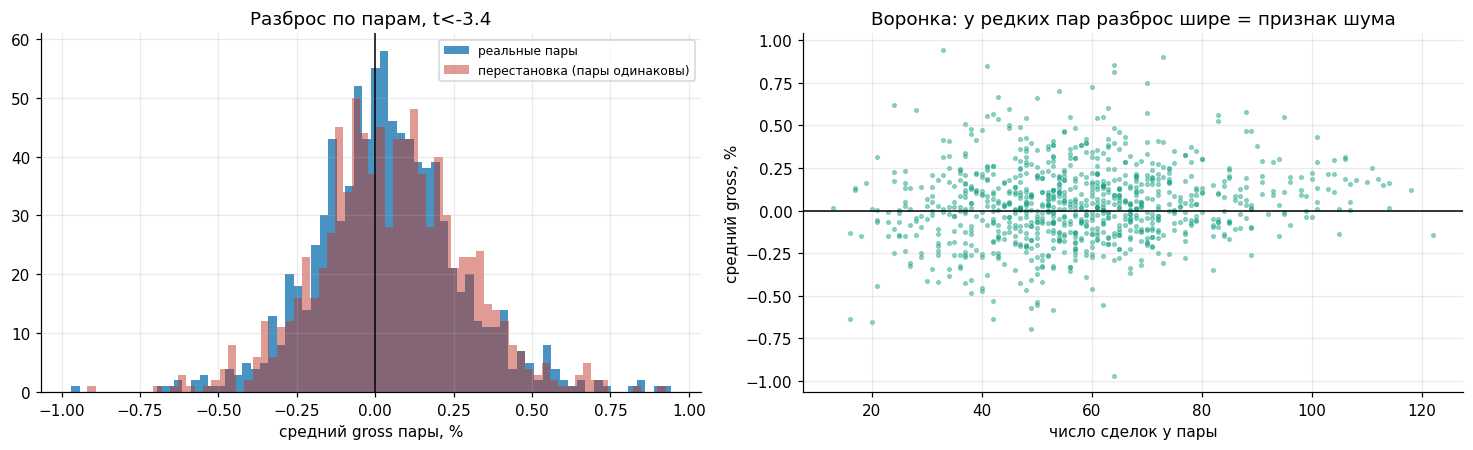

In [2]:
rng = np.random.default_rng(3)
for thr in [-3.4, -3.8]:
    d = D[thr]
    g = d.groupby("pair").gross.agg(["mean", "size", "var"]).dropna()
    g = g[g["size"] >= 10]
    obs_var = g["mean"].var(ddof=1)
    exp_var = float((g["var"] / g["size"]).mean())
    print(f"L={L}д t<{thr}: пар с n>=10: {len(g)}")
    print(f"  дисперсия средних по парам: наблюдаемая {obs_var:.5f}, "
          f"ожидаемая от шума {exp_var:.5f}, отношение {obs_var/exp_var:.3f}")
    icc = max(obs_var - exp_var, 0) / obs_var if obs_var > 0 else 0
    print(f"  доля дисперсии, объяснимая РЕАЛЬНЫМИ различиями пар: {icc*100:.1f}%")

    # перестановочный тест
    vals = d.gross.values
    sizes = g["size"].values
    B = 400
    lo5 = np.empty(B); mn = np.empty(B); cnt = np.empty(B)
    for b in range(B):
        perm = rng.permutation(vals)
        cuts = np.cumsum(sizes)[:-1]
        means = np.array([x.mean() for x in np.split(perm[:sizes.sum()], cuts)])
        lo5[b] = np.percentile(means, 5); mn[b] = means.min()
        cnt[b] = (means < -0.2).sum()
    real_lo5 = np.percentile(g["mean"], 5)
    real_mn = g["mean"].min()
    real_cnt = (g["mean"] < -0.2).sum()
    print(f"  5-й перцентиль средних: реально {real_lo5:+.4f}%, "
          f"перестановка {lo5.mean():+.4f}% (95% интервал "
          f"[{np.percentile(lo5,2.5):+.4f}, {np.percentile(lo5,97.5):+.4f}])")
    print(f"  худшая пара: реально {real_mn:+.4f}%, перестановка {mn.mean():+.4f}%")
    print(f"  пар со средним < -0.2%: реально {real_cnt}, "
          f"перестановка {cnt.mean():.0f} (95% [{np.percentile(cnt,2.5):.0f}, "
          f"{np.percentile(cnt,97.5):.0f}])")
    verdict = ("РЕАЛЬНАЯ гетерогенность есть" if obs_var/exp_var > 1.15
               else "разброс объясним шумом — 'плохих пар' как класса НЕТ")
    print(f"  -> {verdict}\n")

d = D[MAIN]
g = d.groupby("pair").gross.agg(["mean", "size", "var"]).dropna()
g = g[g["size"] >= 10]
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
ax[0].hist(g["mean"], bins=70, color="#2980b9", alpha=0.85, label="реальные пары")
perm = rng.permutation(d.gross.values)
cuts = np.cumsum(g["size"].values)[:-1]
pm = np.array([x.mean() for x in np.split(perm[:g["size"].sum()], cuts)])
ax[0].hist(pm, bins=70, color="#c0392b", alpha=0.5, label="перестановка (пары одинаковы)")
ax[0].axvline(0, color="black", lw=1); ax[0].legend(fontsize=8)
ax[0].set_xlabel("средний gross пары, %"); ax[0].set_title(f"Разброс по парам, t<{MAIN}")
ax[1].scatter(g["size"], g["mean"], s=6, alpha=0.4, color="#16a085")
ax[1].axhline(0, color="black", lw=1)
ax[1].set_xlabel("число сделок у пары"); ax[1].set_ylabel("средний gross, %")
ax[1].set_title("Воронка: у редких пар разброс шире = признак шума")
show("nb11_hetero")

## 2. Переносится ли «плохость» вперёд

Ранжируем пары по среднему gross за 2024 год и смотрим их результат в 2025H1.
Если фильтр «выкинуть худших» работает, нижние децили обязаны остаться внизу.

Контроль надёжности рядом: то же самое разбиение **внутри** одного периода — по
чётности номера сделки. Там «пара изменилась» невозможно по построению, так что
корреляция показывает чистую воспроизводимость оценки. Если она мала, то и вперёд
ловить нечего — оценка среднего по паре просто шумна.

ПЕРЕНОСИМОСТЬ ОЦЕНКИ ПАРЫ
 порог  пар в сравнении  corr вперёд (Pearson)      p  corr вперёд (Spearman)  corr внутри периода  пар в контроле
  -3.4              732                 -0.008 0.8274                  -0.029               -0.006             900
  -3.8              243                 -0.106 0.1005                  -0.059                0.059             728

как читать: 'внутри периода' — верхняя граница того, что вообще можно поймать.
Если она мала, оценка среднего по паре шумна и вперёд переносить нечего.

ДЕЦИЛИ ПО 2024, РЕЗУЛЬТАТ В 2025H1 (t<-3.4, 732 пар)
     пар  fit_ср  test_ср  test_медиана
dec                                    
0     74 -0.4640   0.0598        0.0431
1     73 -0.2341   0.0756        0.0512
2     73 -0.1225   0.0684        0.0887
3     73 -0.0467  -0.0307       -0.0066
4     73  0.0222  -0.0489        0.0128
5     73  0.0816   0.0460        0.0235
6     73  0.1519   0.0372        0.0652
7     73  0.2278  -0.0031        0.0021
8     73  0.3461  -0.0

WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb11_persist.png')

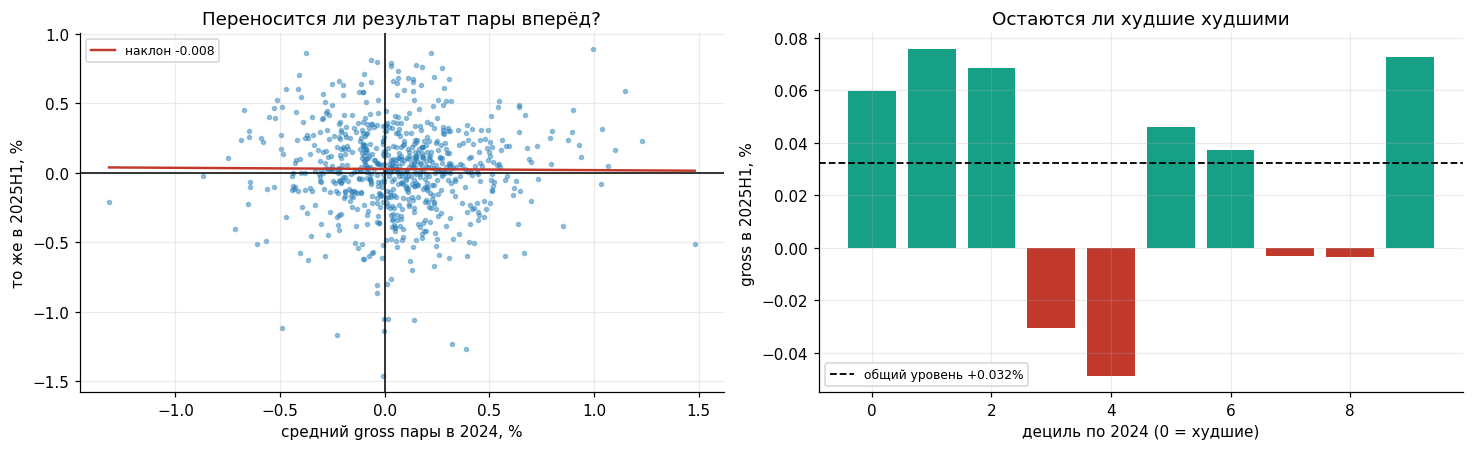

In [3]:
MINN = 12
rows = []
for thr in [-3.4, -3.8]:
    d = D[thr]
    a = d[d.t_in < FIT_END].groupby("pair").gross.agg(["mean", "size"])
    b = d[d.t_in >= FIT_END].groupby("pair").gross.agg(["mean", "size"])
    j = a.join(b, lsuffix="_fit", rsuffix="_test").dropna()
    j = j[(j["size_fit"] >= MINN) & (j["size_test"] >= MINN)]
    pr = sps.pearsonr(j.mean_fit, j.mean_test)
    sr = sps.spearmanr(j.mean_fit, j.mean_test)
    # контроль: чётные против нечётных сделок ВНУТРИ fit-периода
    df = d[d.t_in < FIT_END].sort_values("t_in").copy()
    df["k"] = df.groupby("pair").cumcount()
    o = df[df.k % 2 == 1].groupby("pair").gross.agg(["mean", "size"])
    e = df[df.k % 2 == 0].groupby("pair").gross.agg(["mean", "size"])
    je = o.join(e, lsuffix="_o", rsuffix="_e").dropna()
    je = je[(je["size_o"] >= MINN//2) & (je["size_e"] >= MINN//2)]
    sr_in = sps.spearmanr(je.mean_o, je.mean_e)
    rows.append({"порог": thr, "пар в сравнении": len(j),
                 "corr вперёд (Pearson)": round(float(pr[0]), 3),
                 "p": round(float(pr[1]), 4),
                 "corr вперёд (Spearman)": round(float(sr[0]), 3),
                 "corr внутри периода": round(float(sr_in[0]), 3),
                 "пар в контроле": len(je)})
PER = pd.DataFrame(rows)
print("ПЕРЕНОСИМОСТЬ ОЦЕНКИ ПАРЫ")
print(PER.to_string(index=False))
print()
print("как читать: 'внутри периода' — верхняя граница того, что вообще можно поймать.")
print("Если она мала, оценка среднего по паре шумна и вперёд переносить нечего.")
print()

thr = MAIN
d = D[thr]
a = d[d.t_in < FIT_END].groupby("pair").gross.agg(["mean", "size"])
b = d[d.t_in >= FIT_END].groupby("pair").gross.agg(["mean", "size"])
j = a.join(b, lsuffix="_fit", rsuffix="_test").dropna()
j = j[(j["size_fit"] >= MINN) & (j["size_test"] >= MINN)]
j["dec"] = pd.qcut(j.mean_fit, 10, labels=False)
tab = j.groupby("dec").agg(пар=("mean_fit", "size"), fit_ср=("mean_fit", "mean"),
                           test_ср=("mean_test", "mean"),
                           test_медиана=("mean_test", "median")).round(4)
print(f"ДЕЦИЛИ ПО 2024, РЕЗУЛЬТАТ В 2025H1 (t<{thr}, {len(j)} пар)")
print(tab.to_string())
print()
print(f"общий test-уровень: {j.mean_test.mean():+.4f}%")
print(f"нижний дециль по 2024 -> в 2025 {tab.test_ср.iloc[0]:+.4f}%, "
      f"верхний -> {tab.test_ср.iloc[-1]:+.4f}%, "
      f"спред {tab.test_ср.iloc[-1]-tab.test_ср.iloc[0]:+.4f} п.п.")
print()
print("ЭКСПЕРИМЕНТ 'ВЫКИНУТЬ ХУДШИХ ПО ПРОШЛОМУ':")
dt = d[d.t_in >= FIT_END]
base = dt.gross.mean()
print(f"  базовый test gross (все пары): {base:+.4f}% на {len(dt)} сделках")
for K in [10, 20, 30, 50]:
    bad = set(a[a["size"] >= MINN].nsmallest(int(len(a[a['size']>=MINN])*K/100),
                                             "mean").index)
    keep = dt[~dt.pair.isin(bad)]
    print(f"  выкинуть {K:>2}% худших по 2024 ({len(bad)} пар): test gross "
          f"{keep.gross.mean():+.4f}% на {len(keep)} сделках "
          f"({(keep.gross.mean()-base)*100:+.1f} bps к базе)")

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
ax[0].scatter(j.mean_fit, j.mean_test, s=7, alpha=0.45, color="#2980b9")
ax[0].axhline(0, color="black", lw=1); ax[0].axvline(0, color="black", lw=1)
z = np.polyfit(j.mean_fit, j.mean_test, 1)
xs = np.linspace(j.mean_fit.min(), j.mean_fit.max(), 20)
ax[0].plot(xs, np.polyval(z, xs), color="#c0392b", lw=1.6,
           label=f"наклон {z[0]:+.3f}")
ax[0].set_xlabel("средний gross пары в 2024, %"); ax[0].set_ylabel("то же в 2025H1, %")
ax[0].set_title("Переносится ли результат пары вперёд?"); ax[0].legend(fontsize=8)
ax[1].bar(range(10), tab.test_ср.values,
          color=["#c0392b" if v < 0 else "#16a085" for v in tab.test_ср.values])
ax[1].axhline(base, color="black", ls="--", lw=1.2, label=f"общий уровень {base:+.3f}%")
ax[1].set_xlabel("дециль по 2024 (0 = худшие)"); ax[1].set_ylabel("gross в 2025H1, %")
ax[1].set_title("Остаются ли худшие худшими"); ax[1].legend(fontsize=8)
show("nb11_persist")

## 3. Признаки, наблюдаемые на момент входа

Всё, что ниже, известно **до** сделки — иначе это не фильтр, а подгонка. Из
рефита берём: t-статистику ADF, half-life возврата (из той же регрессии:
`ln 0.5 / ln(1+ρ)`), R² регрессии уровней, саму β, нестабильность β по последним
пяти рефитам, σ спреда. Из окна формации: корреляцию доходностей ног, отношение
их волатильностей. Из вселенной: ликвидность худшей ноги. Плюс устойчивость
самого отбора — в скольких из последних 10 рефитов пара проходила тест.

И фандинг: ожидаемая ставка переноса для **нашей стороны** сделки.

In [4]:
# --- фандинг: накопленный индекс ставки, платимой ЛОНГОМ ---
t0 = time.time()
CF = np.zeros((len(bk.index), len(liq)))
fund_rows = []
for si, s in enumerate(liq):
    f = loader.load_funding(s, TRAIN[0], TRAIN[1])
    if f.empty:
        fund_rows.append({"символ": s, "выплат": 0, "ср. ставка bps": np.nan})
        continue
    pos = bk.index.searchsorted(f.index, side="left")
    add = np.zeros(len(bk.index) + 1)
    np.add.at(add, np.clip(pos, 0, len(bk.index)), f.rate.values)
    CF[:, si] = np.cumsum(add[:-1])
    fund_rows.append({"символ": s, "выплат": len(f),
                      "ср. ставка bps": round(float(f.rate.mean())*1e4, 3)})
FD = pd.DataFrame(fund_rows)
print(f"фандинг загружен за {time.time()-t0:.0f}s; символов с данными "
      f"{FD['выплат'].gt(0).sum()} из {len(liq)}")
print(f"средняя ставка за интервал: медиана {FD['ср. ставка bps'].median():.3f} bps, "
      f"диапазон [{FD['ср. ставка bps'].min():.3f}, {FD['ср. ставка bps'].max():.3f}]")
print("(положительная = лонги платят шортам; на перпах это обычно так)")
print()
print("5 самых дорогих для лонга и 5 самых дешёвых:")
print(FD.nlargest(5, "ср. ставка bps").to_string(index=False))
print(FD.nsmallest(5, "ср. ставка bps").to_string(index=False))

# --- признаки по (рефит x пара) ---
RET = np.diff(bk.M, axis=0)
nb_ = R.nbars
CORR = np.empty((len(R.ends), len(bk.PAIRS)))
VR = np.empty((len(R.ends), len(bk.PAIRS)))
for k, e in enumerate(R.ends):
    W = RET[max(e - nb_ + 1, 0): e]
    sd = W.std(axis=0)
    C = np.corrcoef(W, rowvar=False)
    CORR[k] = C[bk.IY, bk.IX]
    VR[k] = np.maximum(sd[bk.IY], sd[bk.IX]) / np.maximum(np.minimum(sd[bk.IY], sd[bk.IX]), 1e-12)
BSTD = pd.DataFrame(R.B).rolling(5, min_periods=3).std().values
NSEL = pd.DataFrame(((R.T < MAIN) & (R.B > 0)).astype(float)).rolling(
    10, min_periods=5).mean().values
# ожидаемая ставка = средний фандинг за бар на окне формации (мгновенная почти
# всегда 0, потому что выплаты раз в 8 часов)
FRATE = np.empty((len(R.ends), len(liq)))
for k, e in enumerate(R.ends):
    lo = max(e - nb_ + 1, 0)
    FRATE[k] = (CF[e] - CF[lo]) / nb_


def features(d):
    k = R.bar_of[d.i_in.values]
    pi = d.pi.values
    f = pd.DataFrame(index=d.index)
    f["t_ADF"] = R.T[k, pi]
    rho = R.RHO[k, pi]
    with np.errstate(all="ignore"):
        f["half_life_ч"] = np.where(rho < 0, np.log(0.5)/np.log1p(rho), np.nan)
    f["R2_уровней"] = R.R2[k, pi]
    f["beta"] = d.beta.values
    f["откл_beta_от_1"] = np.abs(np.log(np.clip(d.beta.values, 1e-6, None)))
    f["нестаб_beta"] = BSTD[k, pi] / np.abs(np.clip(d.beta.values, 1e-6, None))
    f["sigma_спреда"] = d.sd_pct.values
    f["corr_доходн"] = CORR[k, pi]
    f["отнош_волат"] = VR[k, pi]
    ymin = np.minimum(daily_m[[bk.PAIRS[p][0] for p in pi]].values,
                      daily_m[[bk.PAIRS[p][1] for p in pi]].values)
    f["лог_ликвидн"] = np.log10(ymin)
    f["устойч_отбора"] = NSEL[k, pi]
    fy = FRATE[k, bk.IY[pi]]; fx = FRATE[k, bk.IX[pi]]
    f["фандинг_ставка"] = -d.side.values * (fy - d.beta.values*fx) / d.g.values * 100
    f["глубина_z"] = np.abs(d.z_in.values)
    return f


for thr in [-3.4, -3.8]:
    d = D[thr]
    F = features(d)
    # фактический фандинг за время удержания
    iy = bk.IY[d.pi.values]; ix = bk.IX[d.pi.values]
    dy = CF[d.i_out.values, iy] - CF[d.i_in.values, iy]
    dx = CF[d.i_out.values, ix] - CF[d.i_in.values, ix]
    d["fund"] = -d.side.values * (dy - d.beta.values*dx) / d.g.values * 100
    d["gross_f"] = d.gross + d.fund
    D[thr] = d
    print(f"\nL={L}д t<{thr}: признаков {F.shape[1]}, сделок {len(F)}, "
          f"NaN по признакам: {int(F.isna().any(axis=1).sum())}")
    print(f"  ФАНДИНГ: средний вклад {d.fund.mean():+.4f}% на сделку "
          f"({d.fund.mean()/d.gross.mean()*100:+.0f}% от gross), "
          f"медиана {d.fund.median():+.4f}%, доля сделок где платим "
          f"{(d.fund<0).mean()*100:.0f}%")
    print(f"  gross {d.gross.mean():+.4f}% -> с фандингом {d.gross_f.mean():+.4f}%")

F_MAIN = features(D[MAIN])
print("\nСТАТИСТИКА ПРИЗНАКОВ (t<-3.4)")
print(F_MAIN.describe().T[["mean", "50%", "std", "min", "max"]].round(3).to_string())

фандинг загружен за 1s; символов с данными 43 из 43
средняя ставка за интервал: медиана 0.974 bps, диапазон [-0.092, 1.391]
(положительная = лонги платят шортам; на перпах это обычно так)

5 самых дорогих для лонга и 5 самых дешёвых:
  символ  выплат  ср. ставка bps
 KASUSDT    2136           1.391
  ARUSDT    1623           1.290
 LDOUSDT    1623           1.233
 TRBUSDT    3264           1.213
RUNEUSDT    1623           1.190
 символ  выплат  ср. ставка bps
TIAUSDT    2136          -0.092
BCHUSDT    1623           0.066
BNBUSDT    1623           0.091
SEIUSDT    1623           0.118
GMTUSDT    1623           0.222

L=3д t<-3.4: признаков 13, сделок 52537, NaN по признакам: 202
  ФАНДИНГ: средний вклад +0.0002% на сделку (+0% от gross), медиана +0.0000%, доля сделок где платим 32%
  gross +0.0495% -> с фандингом +0.0497%

L=3д t<-3.8: признаков 13, сделок 25653, NaN по признакам: 90
  ФАНДИНГ: средний вклад -0.0001% на сделку (-0% от gross), медиана +0.0000%, доля сделок где платим 32

## 4. Какие признаки связаны с результатом (обучаемся ТОЛЬКО на 2024)

Для каждого признака делим сделки 2024 года на квинтили и смотрим средний gross.
Важен не столько размах, сколько **монотонность**: если результат ровно растёт от
квинтиля к квинтилю, признак содержит информацию, а не поймал одну аномалию.

Значимость считаем с кластеризацией по паре — иначе 25 тысяч сделок притворятся
25 тысячами независимых наблюдений.

КВИНТИЛИ ПРИЗНАКОВ, gross с фандингом, ТОЛЬКО 2024
       признак  Q1 (низ)     Q2      Q3     Q4  Q5 (верх)   Q5-Q1  монотонность  t Q1  t Q5
    R2_уровней    0.1564 0.0079  0.0528 0.0142     0.0637 -0.0927          -0.1  2.88  2.46
   лог_ликвидн    0.0950 0.0471  0.1063 0.0197     0.0114 -0.0836          -0.7  3.90  0.36
          beta    0.1223 0.0653  0.0337 0.0290     0.0447 -0.0776          -0.7  1.37  0.64
     глубина_z    0.0879 0.1113  0.0502 0.0247     0.0210 -0.0669          -0.9  3.17  2.39
   corr_доходн    0.1360 0.0650  0.0170 0.0026     0.0745 -0.0615          -0.4  2.91  5.67
   отнош_волат    0.0627 0.0754  0.0619 0.0331     0.0619 -0.0008          -0.8  2.50  1.54
         t_ADF    0.0536 0.0919  0.0538 0.0210     0.0748  0.0211           0.0  2.56  2.84
   half_life_ч    0.0209 0.0904  0.0460 0.0730     0.0648  0.0439           0.3 -0.98  2.82
откл_beta_от_1    0.0223 0.0334  0.0543 0.0694     0.1156  0.0933           1.0  1.75  2.13
фандинг_ставка    0.0705 0.03

WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb11_features.png')

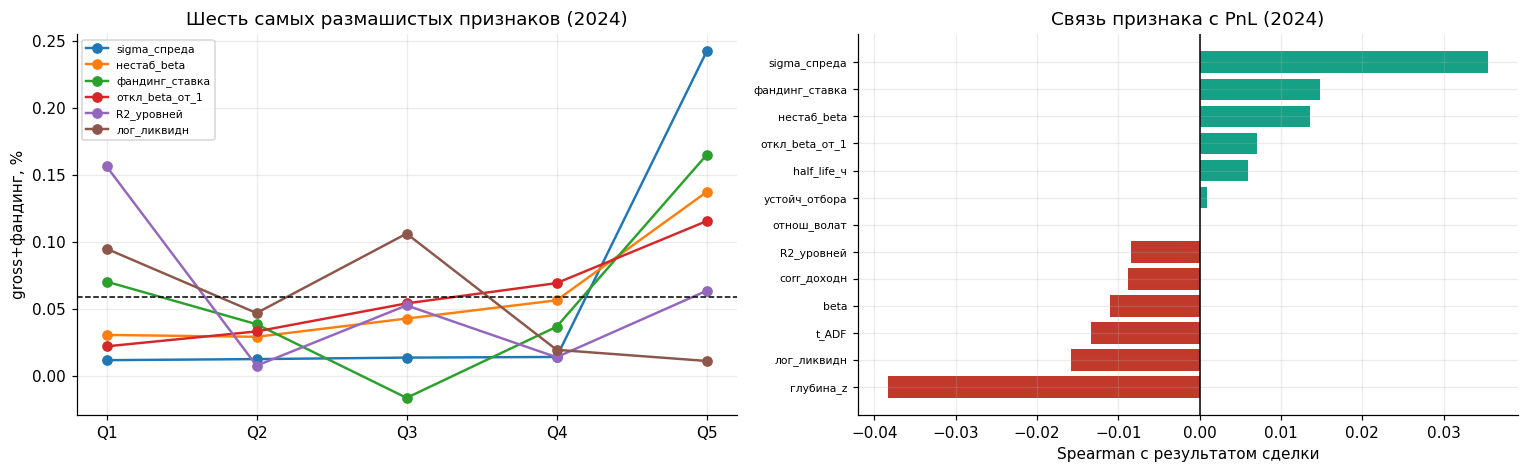

In [5]:
d = D[MAIN]
F = F_MAIN
fit = (d.t_in < FIT_END).values
dfit, Ffit = d[fit], F[fit]

def clu_t(sub):
    m = sub.groupby("pair").gross_f.mean()
    return float(m.mean()/(m.std(ddof=1)/np.sqrt(len(m)))) if len(m) > 2 else np.nan

rows = []
for c in F.columns:
    v = Ffit[c].values
    ok = np.isfinite(v)
    if ok.sum() < 500:
        continue
    q = pd.qcut(pd.Series(v[ok]), 5, labels=False, duplicates="drop")
    sub = dfit[ok].assign(q=q.values)
    m = sub.groupby("q").gross_f.mean()
    if len(m) < 5:
        continue
    sr = sps.spearmanr(np.arange(len(m)), m.values)[0]
    rows.append({"признак": c,
                 "Q1 (низ)": round(m.iloc[0], 4), "Q2": round(m.iloc[1], 4),
                 "Q3": round(m.iloc[2], 4), "Q4": round(m.iloc[3], 4),
                 "Q5 (верх)": round(m.iloc[4], 4),
                 "Q5-Q1": round(m.iloc[4]-m.iloc[0], 4),
                 "монотонность": round(float(sr), 2),
                 "t Q1": round(clu_t(sub[sub.q == 0]), 2),
                 "t Q5": round(clu_t(sub[sub.q == 4]), 2)})
UV = pd.DataFrame(rows).sort_values("Q5-Q1")
print("КВИНТИЛИ ПРИЗНАКОВ, gross с фандингом, ТОЛЬКО 2024")
print(UV.to_string(index=False))
print()
print(f"общий уровень 2024: {dfit.gross_f.mean():+.4f}%")
print()
strong = UV[(UV["монотонность"].abs() >= 0.8) & (UV["Q5-Q1"].abs() >= 0.03)]
print(f"признаки с монотонностью >=0.8 и размахом >=3 bps: {len(strong)}")
print(strong[["признак", "Q1 (низ)", "Q5 (верх)", "Q5-Q1", "монотонность"]].to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
top = UV.reindex(UV["Q5-Q1"].abs().sort_values(ascending=False).index).head(6)
for _, r in top.iterrows():
    ax[0].plot(range(5), [r["Q1 (низ)"], r["Q2"], r["Q3"], r["Q4"], r["Q5 (верх)"]],
               "o-", lw=1.6, label=r["признак"])
ax[0].axhline(dfit.gross_f.mean(), color="black", ls="--", lw=1)
ax[0].set_xticks(range(5)); ax[0].set_xticklabels(["Q1", "Q2", "Q3", "Q4", "Q5"])
ax[0].set_ylabel("gross+фандинг, %"); ax[0].set_title("Шесть самых размашистых признаков (2024)")
ax[0].legend(fontsize=7)
cm = pd.concat([Ffit, dfit.gross_f], axis=1).corr(method="spearman")["gross_f"].drop("gross_f")
cm = cm.sort_values()
ax[1].barh(range(len(cm)), cm.values,
           color=["#c0392b" if v < 0 else "#16a085" for v in cm.values])
ax[1].set_yticks(range(len(cm))); ax[1].set_yticklabels(cm.index, fontsize=7)
ax[1].axvline(0, color="black", lw=1)
ax[1].set_xlabel("Spearman с результатом сделки")
ax[1].set_title("Связь признака с PnL (2024)")
show("nb11_features")

## 5. Проверка фильтра вне периода обучения

Правила строим на 2024 и применяем к 2025H1, не подглядывая. Три варианта:

- **по прошлому**: выкинуть пары, терявшие в 2024;
- **по признакам**: выкинуть худший квинтиль каждого сильного признака;
- **линейная модель**: OLS результата на стандартизованные признаки, обученный на
  2024; на 2025 берём предсказание и смотрим, действительно ли худшие по прогнозу
  оказываются худшими.

Единственная честная метрика — результат на 2025H1, и обязательно рядом с числом
потерянных сделок: фильтр, который убивает 90% сделок, бесполезен даже если
поднимает среднее.

БАЗА test (2025H1): +0.0313% на 17754 сделках, 903 пар

ФИЛЬТРЫ, ОБУЧЕННЫЕ НА 2024, ПРИМЕНЁННЫЕ К 2025H1
                                     правило  сделок  % сделок сохранено  test gross+ф %  Δ к базе, bps
   убрать худший квинтиль: half_life_ч (низ)   14211                80.0          0.0464            1.5
         убрать худший квинтиль: t_ADF (низ)   14245                80.2          0.0389            0.8
убрать худший квинтиль: фандинг_ставка (низ)   15356                86.5          0.0398            0.8
  убрать худший квинтиль: sigma_спреда (низ)   13674                77.0          0.0379            0.7
  убрать худший квинтиль: corr_доходн (верх)   12164                68.5          0.0369            0.6
  убрать худший квинтиль: отнош_волат (верх)   15053                84.8          0.0358            0.4
убрать худший квинтиль: откл_beta_от_1 (низ)   13657                76.9          0.0318            0.0
                выкинуть 10% худших пар 2024   16160           

WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb11_oos.png')

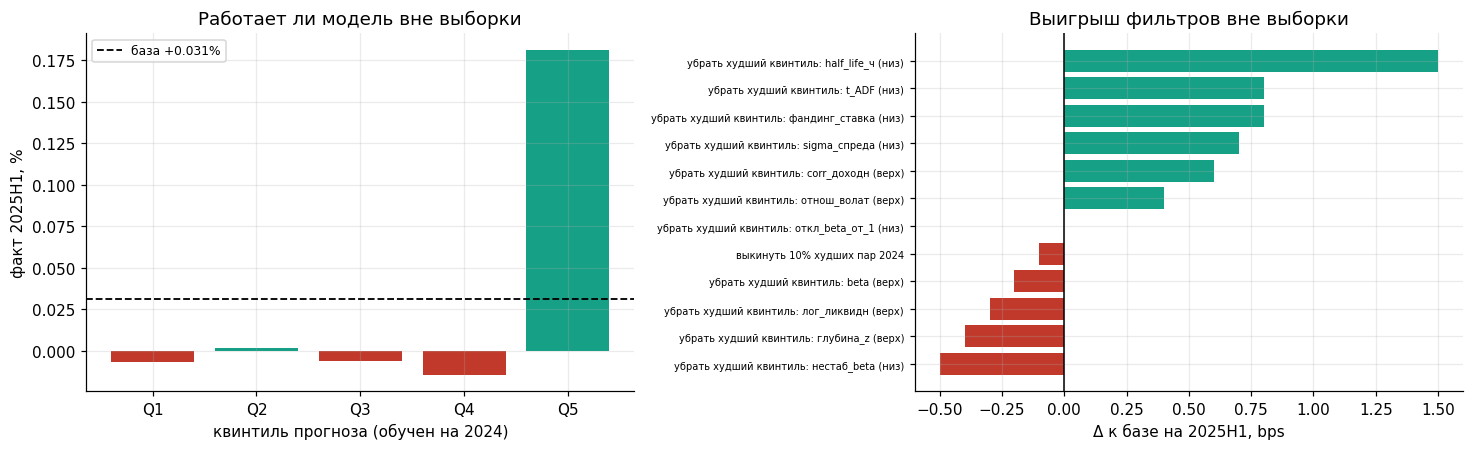

In [6]:
test = (d.t_in >= FIT_END).values
dte, Fte = d[test], F[test]
base = dte.gross_f.mean()
print(f"БАЗА test (2025H1): {base:+.4f}% на {len(dte)} сделках, "
      f"{dte.pair.nunique()} пар\n")

res = []
# --- 1. по прошлому результату пары
pf = dfit.groupby("pair").gross_f.agg(["mean", "size"])
pf = pf[pf["size"] >= MINN]
for K in [10, 20, 30, 50]:
    bad = set(pf.nsmallest(int(len(pf)*K/100), "mean").index)
    m = ~dte.pair.isin(bad)
    res.append({"правило": f"выкинуть {K}% худших пар 2024", "сделок": int(m.sum()),
                "% сделок сохранено": round(m.mean()*100, 1),
                "test gross+ф %": round(dte[m].gross_f.mean(), 4),
                "Δ к базе, bps": round((dte[m].gross_f.mean()-base)*100, 1)})
# --- 2. по признакам: худший квинтиль
for _, r in UV.iterrows():
    c = r["признак"]
    v = Ffit[c].values
    ok = np.isfinite(v)
    if ok.sum() < 500:
        continue
    edges = np.nanpercentile(v[ok], [20, 80])
    side = "низ" if r["Q5-Q1"] > 0 else "верх"
    vt = Fte[c].values
    m = (vt > edges[0]) if side == "низ" else (vt < edges[1])
    m = m & np.isfinite(vt)
    if m.sum() < 200:
        continue
    res.append({"правило": f"убрать худший квинтиль: {c} ({side})",
                "сделок": int(m.sum()), "% сделок сохранено": round(m.mean()*100, 1),
                "test gross+ф %": round(dte[m].gross_f.mean(), 4),
                "Δ к базе, bps": round((dte[m].gross_f.mean()-base)*100, 1)})
OOS = pd.DataFrame(res).sort_values("Δ к базе, bps", ascending=False)
print("ФИЛЬТРЫ, ОБУЧЕННЫЕ НА 2024, ПРИМЕНЁННЫЕ К 2025H1")
print(OOS.to_string(index=False))
print()

# --- 3. линейная модель
cols = [c for c in F.columns if Ffit[c].notna().mean() > 0.9]
Xf = Ffit[cols].copy()
mu_, sg_ = Xf.mean(), Xf.std().replace(0, 1)
Xf = ((Xf - mu_)/sg_).fillna(0.0)
yf = dfit.gross_f.values
w = np.linalg.lstsq(np.c_[np.ones(len(Xf)), Xf.values], yf, rcond=None)[0]
print("КОЭФФИЦИЕНТЫ ЛИНЕЙНОЙ МОДЕЛИ (обучена на 2024, признаки стандартизованы)")
print(pd.Series(w[1:], index=cols).sort_values().round(4).to_string())
Xt = ((Fte[cols] - mu_)/sg_).fillna(0.0)
pred_f = np.c_[np.ones(len(Xf)), Xf.values] @ w
pred_t = np.c_[np.ones(len(Xt)), Xt.values] @ w
qt = pd.qcut(pd.Series(pred_t), 5, labels=False, duplicates="drop")
tab = dte.assign(q=qt.values).groupby("q").gross_f.agg(["mean", "size"]).round(4)
print(f"\nКВИНТИЛИ ПРОГНОЗА НА 2025H1 (in-sample R по 2024: "
      f"{np.corrcoef(pred_f, yf)[0,1]:.3f})")
print(tab.to_string())
print(f"спред Q5-Q1 на test: {tab['mean'].iloc[-1]-tab['mean'].iloc[0]:+.4f} п.п.")
sr = sps.spearmanr(pred_t, dte.gross_f.values)
print(f"Spearman(прогноз, факт) на test: {sr[0]:+.4f} (p={sr[1]:.3g})")
keep = qt.values > 0
print(f"убрать нижний квинтиль прогноза: test gross+ф "
      f"{dte[keep].gross_f.mean():+.4f}% против базы {base:+.4f}% "
      f"на {keep.sum()} сделках ({keep.mean()*100:.0f}% сохранено)")

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
ax[0].bar(range(len(tab)), tab["mean"].values,
          color=["#c0392b" if v < 0 else "#16a085" for v in tab["mean"].values])
ax[0].axhline(base, color="black", ls="--", lw=1.2, label=f"база {base:+.3f}%")
ax[0].set_xticks(range(len(tab))); ax[0].set_xticklabels([f"Q{i+1}" for i in range(len(tab))])
ax[0].set_xlabel("квинтиль прогноза (обучен на 2024)"); ax[0].set_ylabel("факт 2025H1, %")
ax[0].set_title("Работает ли модель вне выборки"); ax[0].legend(fontsize=8)
o = OOS.head(12).iloc[::-1]
ax[1].barh(range(len(o)), o["Δ к базе, bps"].values,
           color=["#16a085" if v > 0 else "#c0392b" for v in o["Δ к базе, bps"].values])
ax[1].set_yticks(range(len(o))); ax[1].set_yticklabels(o["правило"], fontsize=6.5)
ax[1].axvline(0, color="black", lw=1); ax[1].set_xlabel("Δ к базе на 2025H1, bps")
ax[1].set_title("Выигрыш фильтров вне выборки")
show("nb11_oos")

## 7. Экономика лучшей группы: +0.18% на сделку — это торгуемо?

Модель, обученная на 2024, дала на 2025H1 верхний квинтиль **+0.181%** против базы
+0.031% — в шесть раз. Прежде чем радоваться, надо ответить на три вопроса, без
которых число ничего не значит:

1. **Не куплено ли это риском?** Средний рост при пропорциональном росте разброса
   не улучшает ничего. Смотрим `среднее/std` и первый процентиль.
2. **Это σ или что-то ещё?** Самый большой коэффициент модели — `sigma_спреда`
   (+0.159). Экономически это ровно то, что нужно: кост фиксирован, поэтому чем
   больше σ спреда, тем меньшую долю хода он съедает. Но тогда «модель» — просто
   «торгуй волатильные спреды», и проще проверить это напрямую.
3. **Работает ли в оба полугодия?** Одна и та же таблица отдельно на 2024 и 2025H1.

И главное — net при разных костах, потому что вся линия упирается в это.

ЭКОНОМИКА ГРУПП НА 2025H1 (out-of-time: правила с 2024)
                           группа  сделок  сделок/год  gross+ф %  std %  ср/std  q1 %  медиана ч  σ спреда %  t кластер  taker 21 %/год  taker 14 %/год  maker 6 %/год  maker 3 %/год
                ВСЕ сделки 2025H1   17754       35826     0.0313  1.449  0.0216 -3.38        6.0       0.455       1.50          -128.0           -77.9          -20.6            0.9
 верх.квинтиль модели (обуч.2024)    3551        7165     0.1813  2.316  0.0783 -5.57        8.0       0.885       4.58            -4.1             5.9           17.4           21.7
только σ >= 0.825% (порог с 2024)    2385        4812     0.1393  2.613  0.0533 -6.56        8.0       1.040       4.01            -6.8            -0.1            7.6           10.5
   σ высокая И half-life >= 1.40ч    2056        4148     0.2375  2.539  0.0936 -5.39        9.0       1.040       5.23             2.3             8.1           14.7           17.2

ТО ЖЕ НА ОБУЧАЮЩЕМ ПЕРИОДЕ 2024 (

[saved] notebooks\statarb\_out\nb11_economics.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb11_economics.png')

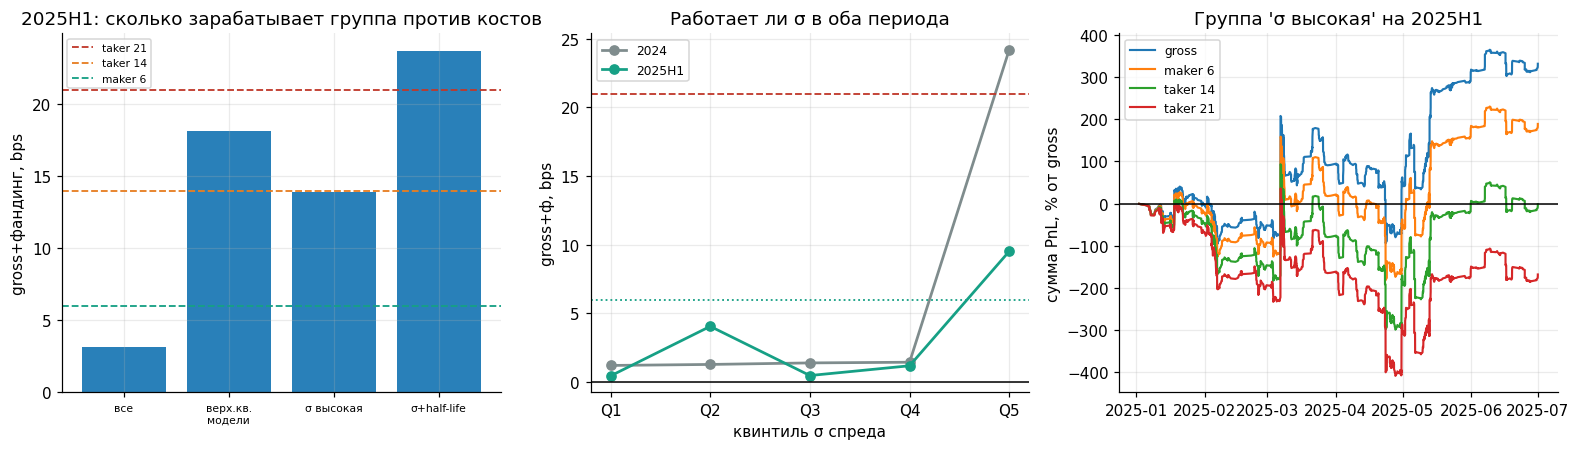

In [7]:
SC = {"taker 21": 0.21, "taker 14": 0.14, "maker 6": 0.06, "maker 3": 0.03}
years_fit = (FIT_END - d.t_in.min()).days / 365.25
years_te = (d.t_in.max() - FIT_END).days / 365.25


def group_stats(sub, tag, yrs):
    g = sub.gross_f
    m = sub.groupby("pair").gross_f.mean()
    r = {"группа": tag, "сделок": len(sub), "сделок/год": int(len(sub)/yrs),
         "gross+ф %": round(g.mean(), 4), "std %": round(g.std(), 3),
         "ср/std": round(g.mean()/g.std(), 4),
         "q1 %": round(np.percentile(g, 1), 2),
         "медиана ч": round(float(sub.hours.median()), 1),
         "σ спреда %": round(sub.sd_pct.median(), 3),
         "t кластер": round(float(m.mean()/(m.std(ddof=1)/np.sqrt(len(m)))), 2)}
    for nm, c in SC.items():
        r[nm + " %/год"] = round(len(sub)/yrs*0.02*(g.mean()-c), 1)
    return r


rows = [group_stats(dte, "ВСЕ сделки 2025H1", years_te)]
top = dte[qt.values == 4]
rows.append(group_stats(top, "верх.квинтиль модели (обуч.2024)", years_te))
# то же, но чистым правилом по σ, порог взят с 2024
sig_thr = np.percentile(Ffit["sigma_спреда"].dropna(), 80)
mm = Fte["sigma_спреда"].values >= sig_thr
rows.append(group_stats(dte[mm], f"только σ >= {sig_thr:.3f}% (порог с 2024)", years_te))
# половинка: σ высокая И half-life не самая короткая
hl_thr = np.percentile(Ffit["half_life_ч"].dropna(), 20)
mm2 = mm & (Fte["half_life_ч"].values >= hl_thr)
rows.append(group_stats(dte[mm2], f"σ высокая И half-life >= {hl_thr:.2f}ч", years_te))
G = pd.DataFrame(rows)
print("ЭКОНОМИКА ГРУПП НА 2025H1 (out-of-time: правила с 2024)")
print(G.to_string(index=False))
print()
print("ТО ЖЕ НА ОБУЧАЮЩЕМ ПЕРИОДЕ 2024 (для сравнения стабильности):")
rows2 = [group_stats(dfit, "ВСЕ сделки 2024", years_fit)]
mf = Ffit["sigma_спреда"].values >= sig_thr
rows2.append(group_stats(dfit[mf], f"только σ >= {sig_thr:.3f}%", years_fit))
rows2.append(group_stats(dfit[mf & (Ffit["half_life_ч"].values >= hl_thr)],
                         "σ высокая И half-life", years_fit))
print(pd.DataFrame(rows2).to_string(index=False))
print()

print("ПОЧЕМУ σ РАБОТАЕТ — арифметика, а не магия:")
for lab, sub in [("низкий σ-квинтиль", dte[Fte["sigma_спреда"].values <
                                           np.percentile(Ffit["sigma_спреда"].dropna(), 20)]),
                 ("высокий σ-квинтиль", dte[mm])]:
    s = sub.sd_pct.median()
    print(f"  {lab:<20}: σ спреда {s:.3f}% -> кост taker = {COST/s:.2f}σ, "
          f"maker = {0.06/s:.2f}σ; факт ход {sub.sigma.mean():+.3f}σ = "
          f"{sub.gross_f.mean():+.4f}%")
print()
print("КОНТРОЛЬ: не съедает ли рост σ всю выгоду через риск?")
for lab, sub in [("все", dte), ("верх.квинтиль модели", top), ("σ высокая", dte[mm])]:
    g = sub.gross_f
    print(f"  {lab:<22}: ср {g.mean():+.4f}%  std {g.std():.3f}%  "
          f"ср/std {g.mean()/g.std():+.4f}  q1 {np.percentile(g,1):+.2f}%  "
          f"q99 {np.percentile(g,99):+.2f}%")
print()
print("КВИНТИЛИ σ ОТДЕЛЬНО ПО ПЕРИОДАМ (порог квинтилей внутри каждого периода):")
for lab, dd, FF in [("2024", dfit, Ffit), ("2025H1", dte, Fte)]:
    v = FF["sigma_спреда"].values
    q = pd.qcut(pd.Series(v), 5, labels=False, duplicates="drop")
    t = dd.assign(q=q.values).groupby("q").agg(
        сделок=("gross_f", "size"), gross=("gross_f", "mean"),
        ход_σ=("sigma", "mean"), σ_спреда=("sd_pct", "median")).round(4)
    print(f"\n{lab}:")
    print(t.to_string())

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
lbl = ["все", "верх.кв.\nмодели", "σ высокая", "σ+half-life"]
vals = [dte.gross_f.mean(), top.gross_f.mean(), dte[mm].gross_f.mean(), dte[mm2].gross_f.mean()]
ax[0].bar(range(4), [v*100 for v in vals], color="#2980b9")
for c, col, nm in [(0.21, "#c0392b", "taker 21"), (0.14, "#e67e22", "taker 14"),
                   (0.06, "#16a085", "maker 6")]:
    ax[0].axhline(c*100, color=col, ls="--", lw=1.2, label=nm)
ax[0].set_xticks(range(4)); ax[0].set_xticklabels(lbl, fontsize=7)
ax[0].set_ylabel("gross+фандинг, bps"); ax[0].legend(fontsize=7)
ax[0].set_title("2025H1: сколько зарабатывает группа против костов")
for lab, dd, FF, c in [("2024", dfit, Ffit, "#7f8c8d"), ("2025H1", dte, Fte, "#16a085")]:
    v = FF["sigma_спреда"].values
    q = pd.qcut(pd.Series(v), 5, labels=False, duplicates="drop")
    t = dd.assign(q=q.values).groupby("q").gross_f.mean()
    ax[1].plot(range(len(t)), t.values*100, "o-", lw=1.8, color=c, label=lab)
ax[1].axhline(21, color="#c0392b", ls="--", lw=1.2)
ax[1].axhline(6, color="#16a085", ls=":", lw=1.2)
ax[1].axhline(0, color="black", lw=1)
ax[1].set_xticks(range(5)); ax[1].set_xticklabels([f"Q{i+1}" for i in range(5)])
ax[1].set_xlabel("квинтиль σ спреда"); ax[1].set_ylabel("gross+ф, bps")
ax[1].set_title("Работает ли σ в оба периода"); ax[1].legend(fontsize=8)
s = dte[mm].sort_values("t_in")
for c, nm in [(0.0, "gross"), (0.06, "maker 6"), (0.14, "taker 14"), (0.21, "taker 21")]:
    ax[2].plot(s.t_in.values, (s.gross_f - c).cumsum().values, lw=1.4, label=nm)
ax[2].axhline(0, color="black", lw=1); ax[2].legend(fontsize=8)
ax[2].set_title("Группа 'σ высокая' на 2025H1"); ax[2].set_ylabel("сумма PnL, % от gross")
show("nb11_economics")

## 8. Проверка σ-фильтра тем же способом, что убил находку nb10

nb10 научил: результат может целиком висеть на двух символах. Прогоняем группу
«σ высокая И half-life ≥ порога» через те же проверки:

- удаление каждого символа по одному;
- концентрация по парам (вклад топ-10);
- по месяцам;
- сколько позиций держится **одновременно** — от этого зависит, влезает ли всё в
  капитал и не является ли доходность «%/год» фикцией.

Последний пункт важнее, чем кажется. Оценки «%/год» выше считались как
`сделок/год × 2% gross × net`, то есть в предположении, что каждый сигнал берётся.
Если одновременно открыто 4 позиции, то занято 8% капитала, и цифра честная (даже
консервативная — размер позиции можно увеличить). Если 150, то в лимит gross ≤100%
не влезает и половину сигналов придётся пропустить.

группа: 2056 сделок на 2025H1, 644 пар, gross+ф +0.2375%
        5980 сделок на 2024, 842 пар, gross+ф +0.2643%

УДАЛЕНИЕ ПО ОДНОМУ СИМВОЛУ
период  база %  мин без символа %        кто  макс без символа %  все >0  падение от худшего %
  2024  0.2643             0.1913    JTOUSDT              0.2949    True                  28.0
2025H1  0.2375             0.1588 PEOPLEUSDT              0.3527    True                  33.0

пять самых влиятельных символов на 2025H1 (вклад в среднюю сделку, п.п.):
PEOPLEUSDT    0.0788
RUNEUSDT      0.0785
TRBUSDT       0.0595
ENSUSDT       0.0371
XLMUSDT       0.0329
  2024: без TRB/XMR gross+ф +0.3214% против +0.2643% на 5249 из 5980 сделок
  2025H1: без TRB/XMR gross+ф +0.1755% против +0.2375% на 1743 из 2056 сделок

вклад топ-10 пар: 30% итога при 2% сделок
доля пар с положительным итогом: 58% из 644



2024 по месяцам: плюсовых 10 из 12; значения +0.24, +0.48, +0.03, +0.51, -0.05, -0.14, +0.33, +0.17, +0.16, +0.70, +0.41, +0.48
2025H1 по месяцам: плюсовых 5 из 6; значения +0.07, -0.12, +0.29, +0.14, +0.71, +0.08

СКОЛЬКО ПОЗИЦИЙ ОДНОВРЕМЕННО (влезает ли в капитал)
  все сделки 2025H1     : максимум  136, в среднем   36.3 позиций -> занято gross  72.7% капитала при 2% на позицию (максимум   272%)
  σ+half-life 2025H1    : максимум   76, в среднем    5.7 позиций -> занято gross  11.5% капитала при 2% на позицию (максимум   152%)
  σ+half-life 2024      : максимум   80, в среднем    7.8 позиций -> занято gross  15.6% капитала при 2% на позицию (максимум   160%)

при среднем 5.7 позиций капитал простаивает: занято 11.5% из 100%.
значит размер позиции можно поднять примерно в 0.7x, чтобы
пиковая загрузка дошла до 100% — доходность масштабируется на тот же множитель,
и просадка тоже. Аккуратная оценка при пике 100% gross:
   taker 21 :    +1.5%/год
   taker 14 :    +5.3%/год
   maker 6  : 

C:\Users\nvisary\AppData\Local\Temp\ipykernel_49328\3772601428.py:38: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bm = sub.groupby(sub.t_in.dt.to_period("M")).gross_f.agg(["mean", "size"])
C:\Users\nvisary\AppData\Local\Temp\ipykernel_49328\3772601428.py:38: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bm = sub.groupby(sub.t_in.dt.to_period("M")).gross_f.agg(["mean", "size"])
C:\Users\nvisary\AppData\Local\Temp\ipykernel_49328\3772601428.py:86: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bm = sub.groupby(sub.t_in.dt.to_period("M")).gross_f.mean()


[saved] notebooks\statarb\_out\nb11_sigma_robust.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb11_sigma_robust.png')

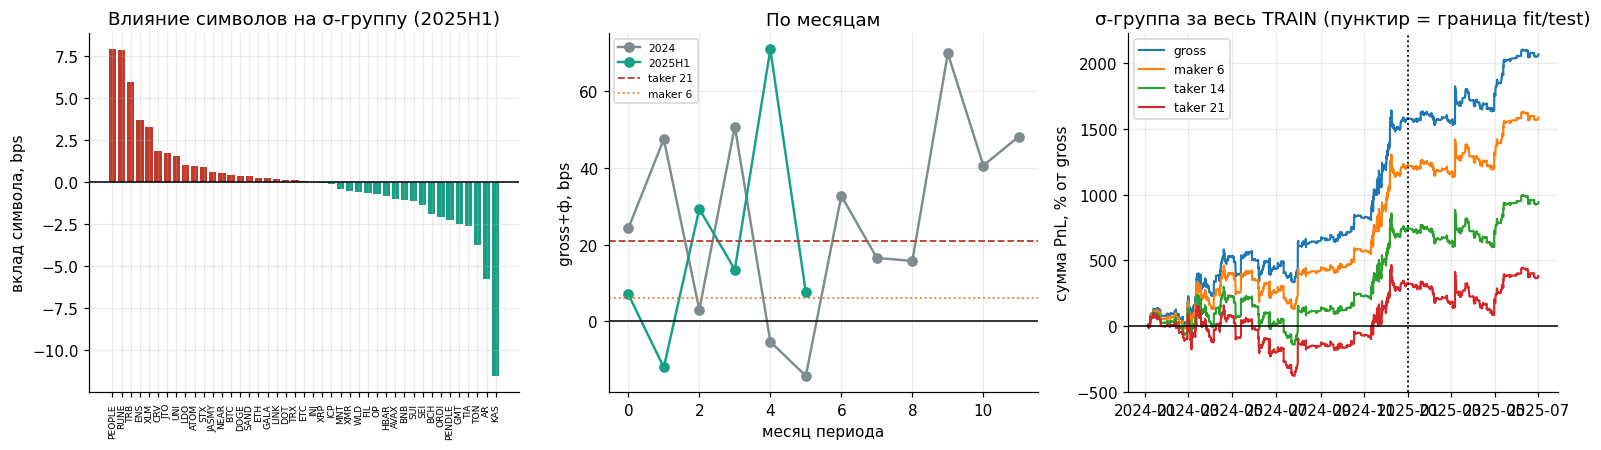

In [8]:
SIG = dte[mm2].copy()          # σ высокая И half-life, 2025H1
SIGF = dfit[mf & (Ffit["half_life_ч"].values >= hl_thr)].copy()
print(f"группа: {len(SIG)} сделок на 2025H1, {SIG.pair.nunique()} пар, "
      f"gross+ф {SIG.gross_f.mean():+.4f}%")
print(f"        {len(SIGF)} сделок на 2024, {SIGF.pair.nunique()} пар, "
      f"gross+ф {SIGF.gross_f.mean():+.4f}%\n")

syms = sorted({s for p in SIG.pair.unique() for s in p.split("/")})
rows = []
for lab, sub in [("2024", SIGF), ("2025H1", SIG)]:
    base = sub.gross_f.mean()
    loo = pd.Series({s: sub[~sub.pair.str.contains(s, regex=False)].gross_f.mean()
                     for s in syms}).dropna()
    rows.append({"период": lab, "база %": round(base, 4),
                 "мин без символа %": round(loo.min(), 4), "кто": loo.idxmin(),
                 "макс без символа %": round(loo.max(), 4),
                 "все >0": bool((loo > 0).all()),
                 "падение от худшего %": round((1-loo.min()/base)*100, 0)})
print("УДАЛЕНИЕ ПО ОДНОМУ СИМВОЛУ")
print(pd.DataFrame(rows).to_string(index=False))
print()
loo = pd.Series({s: SIG[~SIG.pair.str.contains(s, regex=False)].gross_f.mean()
                 for s in syms}).dropna()
print("пять самых влиятельных символов на 2025H1 (вклад в среднюю сделку, п.п.):")
print((SIG.gross_f.mean() - loo).sort_values(ascending=False).head(5).round(4).to_string())
TOX = ["TRBUSDT", "XMRUSDT"]
for lab, sub in [("2024", SIGF), ("2025H1", SIG)]:
    k = ~sub.pair.str.contains("|".join(TOX))
    print(f"  {lab}: без TRB/XMR gross+ф {sub[k].gross_f.mean():+.4f}% против "
          f"{sub.gross_f.mean():+.4f}% на {k.sum()} из {len(sub)} сделок")
print()
bp = SIG.groupby("pair").gross_f.agg(["sum", "size"]).sort_values("sum", ascending=False)
print(f"вклад топ-10 пар: {bp.head(10)['sum'].sum()/bp['sum'].sum()*100:.0f}% итога "
      f"при {bp.head(10)['size'].sum()/len(SIG)*100:.0f}% сделок")
print(f"доля пар с положительным итогом: {(bp['sum']>0).mean()*100:.0f}% из {len(bp)}")
print()
for lab, sub in [("2024", SIGF), ("2025H1", SIG)]:
    bm = sub.groupby(sub.t_in.dt.to_period("M")).gross_f.agg(["mean", "size"])
    print(f"{lab} по месяцам: плюсовых {(bm['mean']>0).sum()} из {len(bm)}; "
          f"значения " + ", ".join(f"{v:+.2f}" for v in bm['mean'].round(2)))
print()


def concurrency(sub):
    ev = [(a, 1) for a in sub.i_in.values] + [(b, -1) for b in sub.i_out.values]
    ev.sort(key=lambda e: (e[0], e[1]))
    cur = best = 0
    for _, dd in ev:
        cur += dd; best = max(best, cur)
    span = sub.i_out.max() - sub.i_in.min()
    return best, float((sub.i_out - sub.i_in).sum()) / span


print("СКОЛЬКО ПОЗИЦИЙ ОДНОВРЕМЕННО (влезает ли в капитал)")
for lab, sub in [("все сделки 2025H1", dte), ("σ+half-life 2025H1", SIG),
                 ("σ+half-life 2024", SIGF)]:
    mx, avg = concurrency(sub)
    print(f"  {lab:<22}: максимум {mx:>4}, в среднем {avg:>6.1f} позиций "
          f"-> занято gross {avg*2:>5.1f}% капитала при 2% на позицию "
          f"(максимум {mx*2:>5.0f}%)")
print()
mx, avg = concurrency(SIG)
print(f"при среднем {avg:.1f} позиций капитал простаивает: занято {avg*2:.1f}% из 100%.")
print(f"значит размер позиции можно поднять примерно в {100/max(mx*2,1):.1f}x, чтобы")
print(f"пиковая загрузка дошла до 100% — доходность масштабируется на тот же множитель,")
print(f"и просадка тоже. Аккуратная оценка при пике 100% gross:")
for nm, c in SC.items():
    k = 100/max(mx*2, 1)
    print(f"   {nm:<9}: {len(SIG)/years_te*0.02*(SIG.gross_f.mean()-c)*k:+7.1f}%/год")
print()
print("ВАЖНО про границы этого вывода:")
print(" - 2024 и 2025H1 — оба внутри TRAIN. Настоящий holdout (2025-07..2026-04)")
print("   по-прежнему заперт, и порог σ подобран на 2024 (одна ручка).")
print(" - Проскальзывание 5 bps/сторону в модели костов; nb08 §1 намерил Roll-полуспред")
print("   1.11 bps на минутках, но на волатильных спредах он может быть выше.")

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
s = (SIG.gross_f.mean() - loo).sort_values(ascending=False)
ax[0].bar(range(len(s)), s.values*100,
          color=["#c0392b" if v > 0 else "#16a085" for v in s.values])
ax[0].set_xticks(range(len(s))); ax[0].set_xticklabels([x[:-4] for x in s.index],
                                                       rotation=90, fontsize=6)
ax[0].axhline(0, color="black", lw=1); ax[0].set_ylabel("вклад символа, bps")
ax[0].set_title("Влияние символов на σ-группу (2025H1)")
for lab, sub, c in [("2024", SIGF, "#7f8c8d"), ("2025H1", SIG, "#16a085")]:
    bm = sub.groupby(sub.t_in.dt.to_period("M")).gross_f.mean()
    ax[1].plot(range(len(bm)), bm.values*100, "o-", lw=1.6, color=c, label=lab)
ax[1].axhline(21, color="#c0392b", ls="--", lw=1.2, label="taker 21")
ax[1].axhline(6, color="#e67e22", ls=":", lw=1.2, label="maker 6")
ax[1].axhline(0, color="black", lw=1)
ax[1].set_xlabel("месяц периода"); ax[1].set_ylabel("gross+ф, bps")
ax[1].set_title("По месяцам"); ax[1].legend(fontsize=7)
allsig = pd.concat([SIGF, SIG]).sort_values("t_in")
for c, nm in [(0.0, "gross"), (0.06, "maker 6"), (0.14, "taker 14"), (0.21, "taker 21")]:
    ax[2].plot(allsig.t_in.values, (allsig.gross_f - c).cumsum().values, lw=1.4, label=nm)
ax[2].axvline(FIT_END, color="black", ls=":", lw=1.2)
ax[2].axhline(0, color="black", lw=1); ax[2].legend(fontsize=8)
ax[2].set_title("σ-группа за весь TRAIN (пунктир = граница fit/test)")
ax[2].set_ylabel("сумма PnL, % от gross")
show("nb11_sigma_robust")

## 6. Итог

In [9]:
print("1. СУЩЕСТВУЮТ ЛИ 'ПЛОХИЕ ПАРЫ' КАК КЛАСС\n")
for thr in [-3.4, -3.8]:
    dd = D[thr]
    g = dd.groupby("pair").gross.agg(["mean", "size", "var"]).dropna()
    g = g[g["size"] >= 10]
    ov, ev = g["mean"].var(ddof=1), float((g["var"]/g["size"]).mean())
    print(f"   t<{thr}: дисперсия средних / шумовая = {ov/ev:.3f}, "
          f"реальных различий {max(ov-ev,0)/ov*100:.0f}% дисперсии")
print("\n2. ПЕРЕНОСИМОСТЬ")
print(PER.to_string(index=False))
print("\n3. ФАНДИНГ")
for thr in [-3.4, -3.8]:
    dd = D[thr]
    print(f"   t<{thr}: {dd.fund.mean():+.4f}% на сделку "
          f"({dd.fund.mean()/dd.gross.mean()*100:+.0f}% от gross)")
print("\n4. ЛУЧШИЕ ФИЛЬТРЫ ВНЕ ВЫБОРКИ (2025H1)")
print(OOS.head(6).to_string(index=False))
print(f"\n   Spearman(прогноз модели, факт) на test: {sr[0]:+.4f}")

1. СУЩЕСТВУЮТ ЛИ 'ПЛОХИЕ ПАРЫ' КАК КЛАСС

   t<-3.4: дисперсия средних / шумовая = 1.033, реальных различий 3% дисперсии
   t<-3.8: дисперсия средних / шумовая = 1.085, реальных различий 8% дисперсии

2. ПЕРЕНОСИМОСТЬ
 порог  пар в сравнении  corr вперёд (Pearson)      p  corr вперёд (Spearman)  corr внутри периода  пар в контроле
  -3.4              732                 -0.008 0.8274                  -0.029               -0.006             900
  -3.8              243                 -0.106 0.1005                  -0.059                0.059             728

3. ФАНДИНГ
   t<-3.4: +0.0002% на сделку (+0% от gross)
   t<-3.8: -0.0001% на сделку (-0% от gross)

4. ЛУЧШИЕ ФИЛЬТРЫ ВНЕ ВЫБОРКИ (2025H1)
                                     правило  сделок  % сделок сохранено  test gross+ф %  Δ к базе, bps
   убрать худший квинтиль: half_life_ч (низ)   14211                80.0          0.0464            1.5
         убрать худший квинтиль: t_ADF (низ)   14245                80.2          0.038